In [185]:
import numpy as np
import scanpy
import phate
import scprep
import matplotlib.pyplot as plt
import magic
import leidenalg
import seaborn as sns
from sklearn.preprocessing import scale
import pandas as pd
import meld
from collections import defaultdict

In [4]:
acute = scanpy.read_h5ad('data/acute_tcells.h5ad')
chronic = scanpy.read_h5ad('data/chronic_tcells.h5ad')

In [5]:
adata = scanpy.concat((acute,chronic))
adata.obs['batch'] = adata.obs['batch'].astype('category')

In [49]:
phate_op = phate.PHATE(random_state=42, n_jobs=-1, knn=30)
adata.obsm['X_phate'] = phate_op.fit_transform(adata.to_df())

Calculating PHATE...
  Running PHATE on 44190 observations and 14152 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 20.76 seconds.
    Calculating KNN search...
    Calculated KNN search in 60.94 seconds.
    Calculating affinities...
    Calculated affinities in 6.48 seconds.
  Calculated graph and diffusion operator in 88.73 seconds.
  Calculating landmark operator...
    Calculating SVD...
    Calculated SVD in 19.59 seconds.
    Calculating KMeans...
    Calculated KMeans in 5.31 seconds.
  Calculated landmark operator in 27.07 seconds.
  Calculating optimal t...
    Automatically selected t = 24
  Calculated optimal t in 2.11 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.64 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 4.61 seconds.
Calculated PHATE in 123.18 seconds.


In [46]:
markers = {'Proliferation':["Mki67", 'Birc5', 'Pclaf', 'Top2a', 'Hist1h1b', 'Stmn1'],
           'Naive': ["Tcf7", "Lef1", "Ccr7", "Sell",],
           'Stem-like':['Tcf7', 'Xcl1', 'Slamf6'],
           'Ifn-signaling': ["Irf7", "Stat1", 'Isg20', 'Ifit1', 'Ifit3', 'Isg15'],
           'Effector': ["Nkg7", "Ccl5", "Ly6c2", "Lgals1", "Prf1", "Klrg1", "Cx3cr1", "Klre1", "Zeb2", "Gzma",],
           'Memory': ["Il7r", "Malat1", "Cxcr3", "Ltb", "Gpr183",]}

In [7]:
markers = ["Mki67", 'Birc5', 'Pclaf', 'Top2a', 'Hist1h1b', 'Stmn1',
           "Tcf7", "Lef1", "Ccr7", "Sell",
           "Slamf6", 'Xcl1',
           "Il7r", "Malat1", "Cxcr3", "Ltb", "Gpr183",
           "Irf7", "Stat1", 'Isg20', 'Ifit1', 'Ifit3', 'Isg15',
           "Nkg7", "Ccl5", "Ly6c2", "Lgals1", "Prf1", "Klrg1", "Cx3cr1", "Klre1", "Zeb2", "Gzma",
           "Pdcd1", "Cd101", "Havcr2"]

In [39]:
gene_embedding_results = np.load('results/GSPA_QR_without_regression.npz', allow_pickle=True)

In [43]:
data_ae = gene_embedding_results['signal_embedding']
localization = gene_embedding_results['localization_score']
hvgs = gene_embedding_results['genes']

In [66]:
gene_phate_op = phate.PHATE(random_state=42)
data_phate = gene_phate_op.fit_transform(data_ae)

Calculating PHATE...
  Running PHATE on 1416 observations and 128 variables.
  Calculating graph and diffusion operator...
    Calculating PCA...
    Calculated PCA in 0.03 seconds.
    Calculating KNN search...
    Calculated KNN search in 0.19 seconds.
    Calculating affinities...
    Calculated affinities in 0.01 seconds.
  Calculated graph and diffusion operator in 0.23 seconds.
  Calculating optimal t...
    Automatically selected t = 29
  Calculated optimal t in 0.84 seconds.
  Calculating diffusion potential...
  Calculated diffusion potential in 0.32 seconds.
  Calculating metric MDS...
  Calculated metric MDS in 1.74 seconds.
Calculated PHATE in 3.14 seconds.


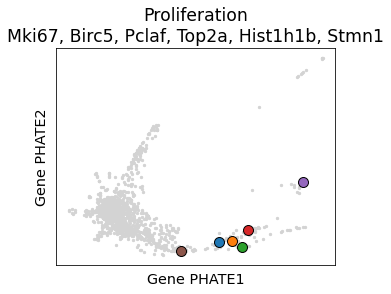

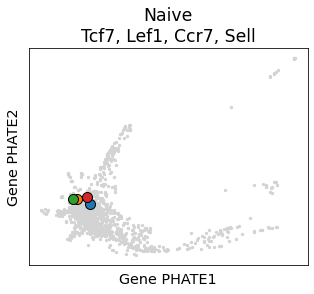

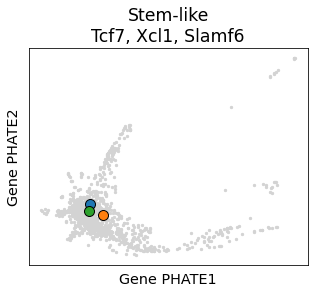

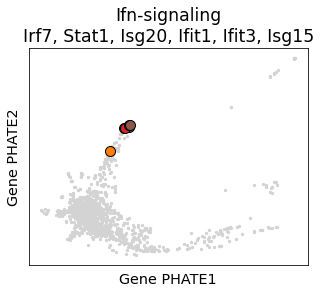

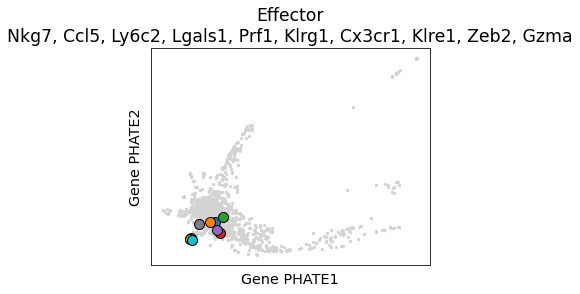

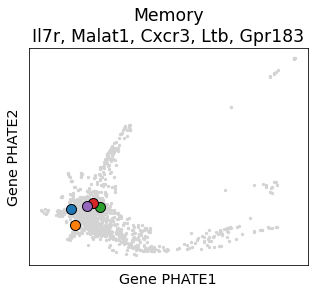

In [47]:
for name,genes in markers.items():
    fig, ax = plt.subplots(1,1, figsize=(5,4))
    scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c='lightgray', ax=ax,
                          title=f'{name}\n{", ".join(genes)}', label_prefix='Gene PHATE')
    for gene in genes:
        scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), mask=hvgs == gene,
                              s=100, ax=ax, edgecolor='black')

In [76]:
gene_clusters = np.array(leidenalg.find_partition(gene_phate_op.graph.to_igraph(), 
                                                  leidenalg.ModularityVertexPartition,
                                                  seed=0).membership)

<AxesSubplot:title={'center':'Gene clusters'}, xlabel='Gene PHATE1', ylabel='Gene PHATE2'>

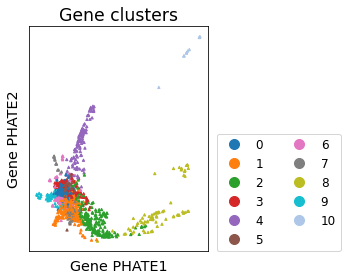

In [211]:
scprep.plot.scatter2d(data_phate, ticks=None, figsize=(5,4), c=gene_clusters, dpi=200, filename='figures/gene_clusters.png',
                          title='Gene clusters', label_prefix='Gene PHATE', legend_loc=(1.05,0), marker='^')

In [277]:
gene_clusters = pd.Series(gene_clusters, index=hvgs)

In [174]:
gene_clusters.to_csv('results/gene_cluster_assignments.csv')

In [280]:
gene_summary = pd.concat((gene_clusters, localization), axis=1)
gene_summary.columns = ['gene_clusters', 'localization_score']

In [284]:
gene_summary.to_csv('results/gene_summary.csv')

In [65]:
magic_op = magic.MAGIC()
data_magic = magic_op.fit_transform(adata.to_df(), genes=hvgs, graph=phate_op.graph)

Calculating MAGIC...
  Running MAGIC on 44190 cells and 14152 genes.
  Using precomputed graph and diffusion operator...
  Calculating imputation...
  Calculated imputation in 21.74 seconds.
Calculated MAGIC in 23.06 seconds.


In [214]:
 pd.Series(gene_clusters, index=hvgs).loc[['Pdcd1', 'Tox', 'Klrg1']]

Pdcd1    7
Tox      7
Klrg1    1
dtype: int64

In [99]:
for name, genes in markers.items():
    print (name, pd.Series(gene_clusters, index=hvgs).loc[genes])

Proliferation Mki67       8
Birc5       2
Pclaf       8
Top2a       8
Hist1h1b    8
Stmn1       2
dtype: int64
Naive Tcf7    3
Lef1    3
Ccr7    3
Sell    3
dtype: int64
Stem-like Tcf7      3
Xcl1      2
Slamf6    5
dtype: int64
Ifn-signaling Irf7     4
Stat1    4
Isg20    4
Ifit1    4
Ifit3    4
Isg15    4
dtype: int64
Effector Nkg7      1
Ccl5      1
Ly6c2     1
Lgals1    1
Prf1      1
Klrg1     1
Cx3cr1    1
Klre1     1
Zeb2      1
Gzma      1
dtype: int64
Memory Il7r      3
Malat1    0
Cxcr3     5
Ltb       5
Gpr183    3
dtype: int64


In [118]:
cmap = dict([(sample,plt.cm.Paired.colors[:6][i]) for i,sample in enumerate(['AcuteD4', 'ChronicD4', 'AcuteD8', 'ChronicD8', 'Acute40', 'Chronic40'])])

In [180]:
meld_op = meld.MELD()
meld_op.graph = phate_op.graph

all_sample_densities = meld_op.transform(adata.obs['batch'])
all_sample_likelihoods = meld.normalize_densities(all_sample_densities)

del(meld_op)

In [186]:
prob_per_condition = defaultdict(list)
for gene in hvgs:
    for condition in cmap.keys():
        prob_per_condition[gene].append(np.mean(np.array(data_magic[gene]) * np.array(all_sample_likelihoods[condition])))

In [188]:
prob_per_condition = pd.DataFrame(prob_per_condition).T
prob_per_condition = (prob_per_condition.T / np.array(prob_per_condition.sum(axis=1))).T
prob_per_condition.columns = cmap.keys()

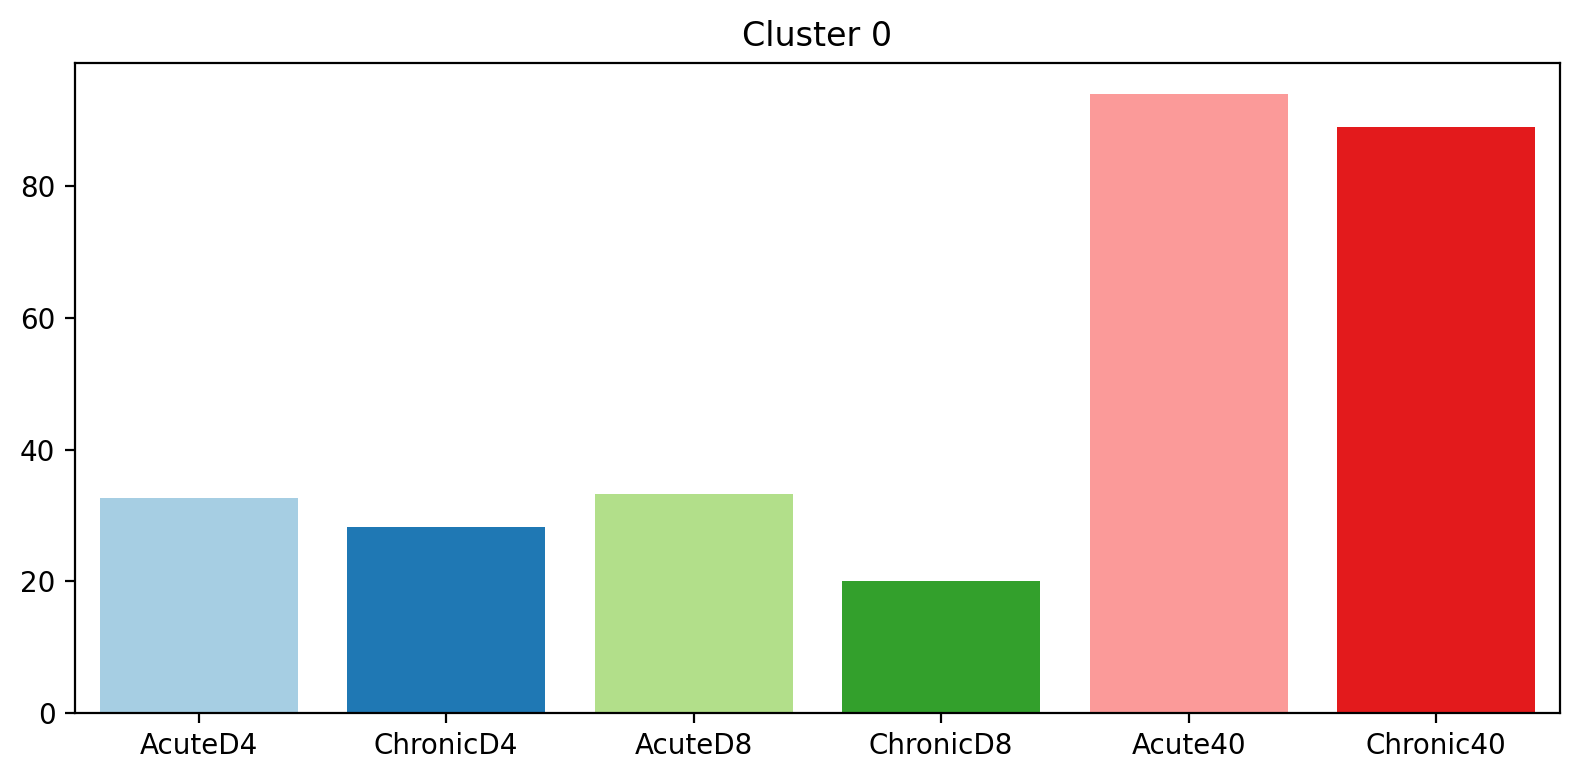

<Figure size 432x288 with 0 Axes>

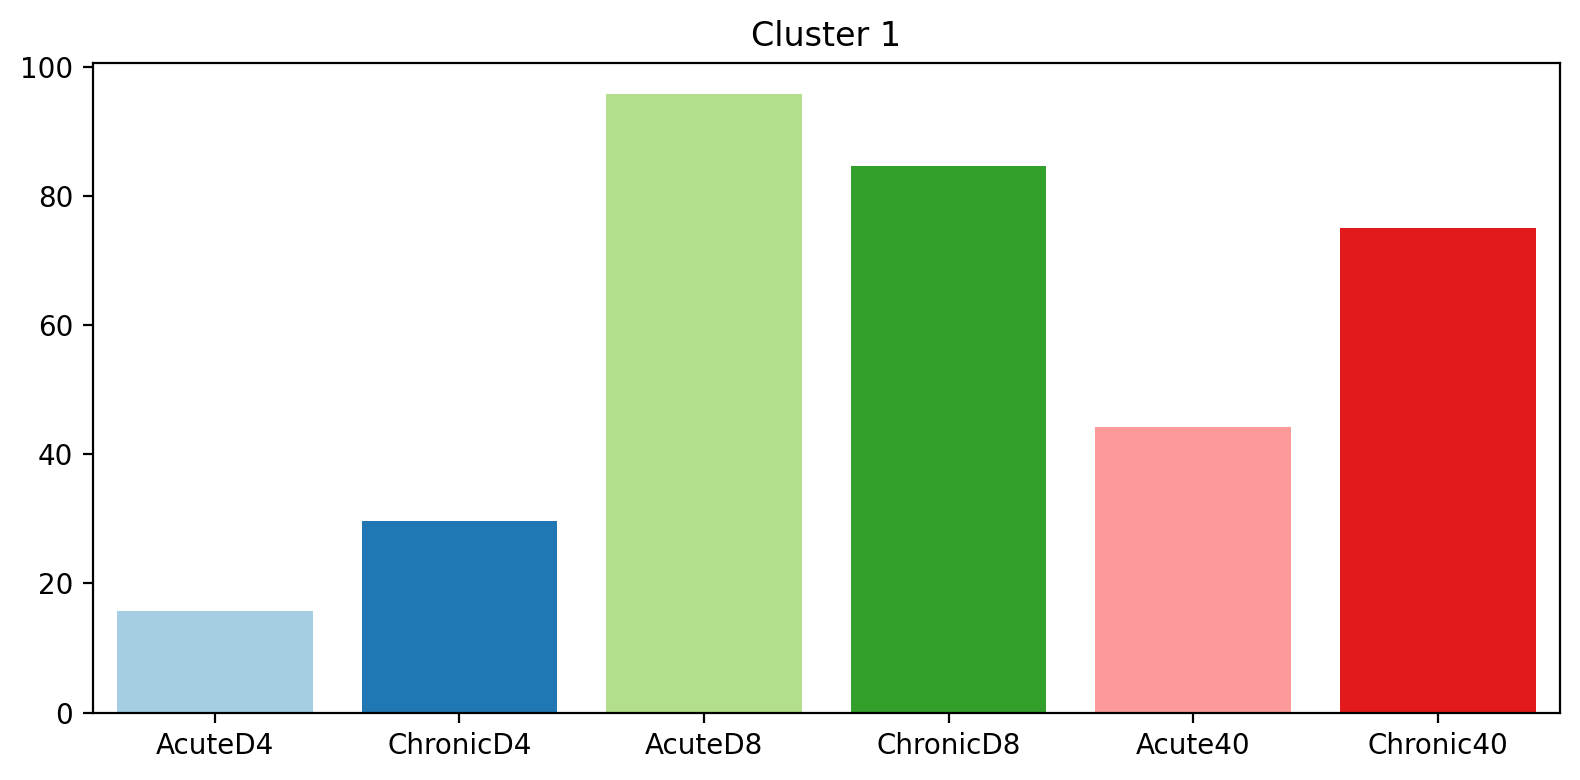

<Figure size 432x288 with 0 Axes>

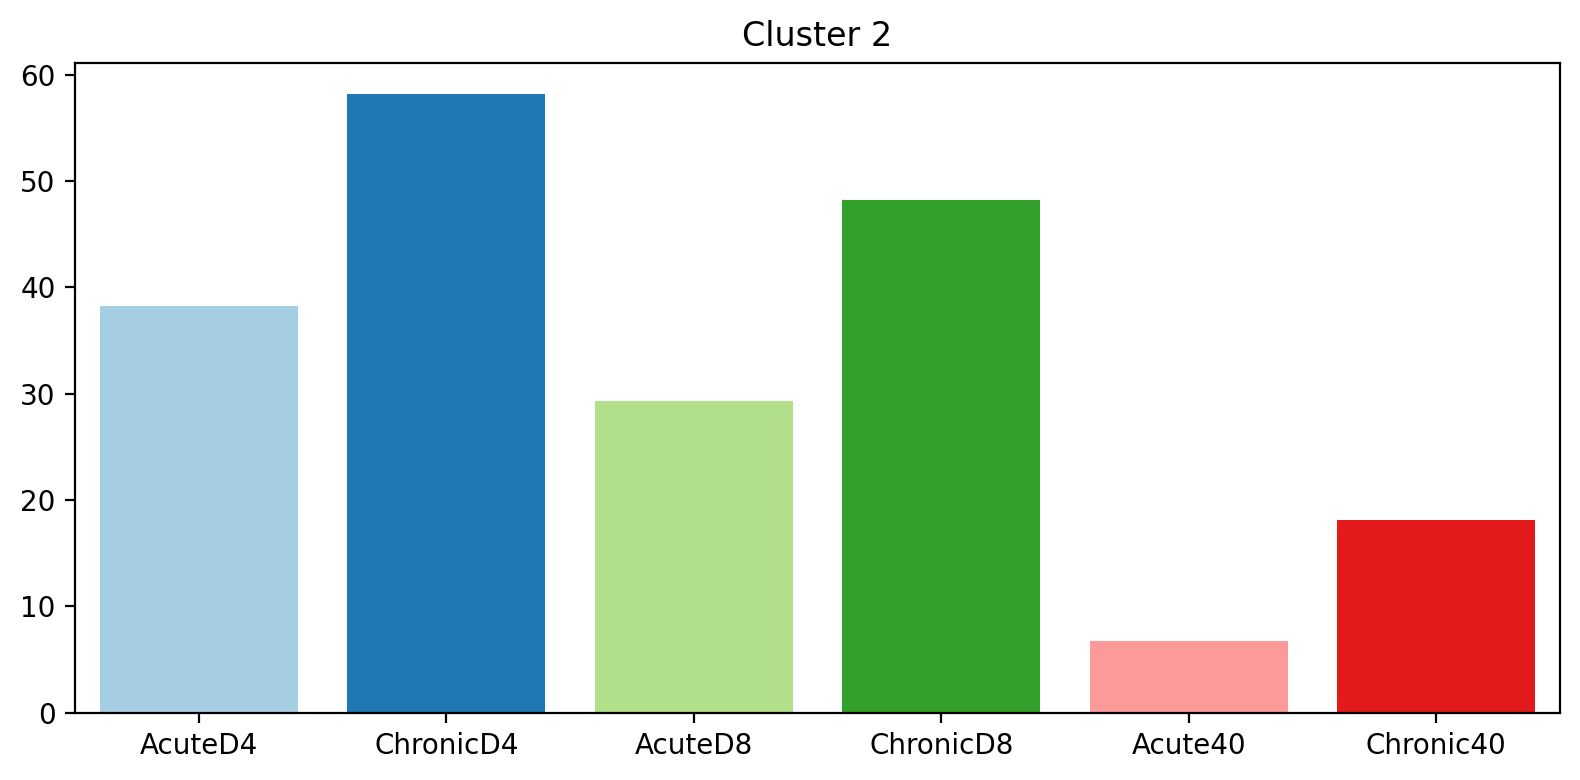

<Figure size 432x288 with 0 Axes>

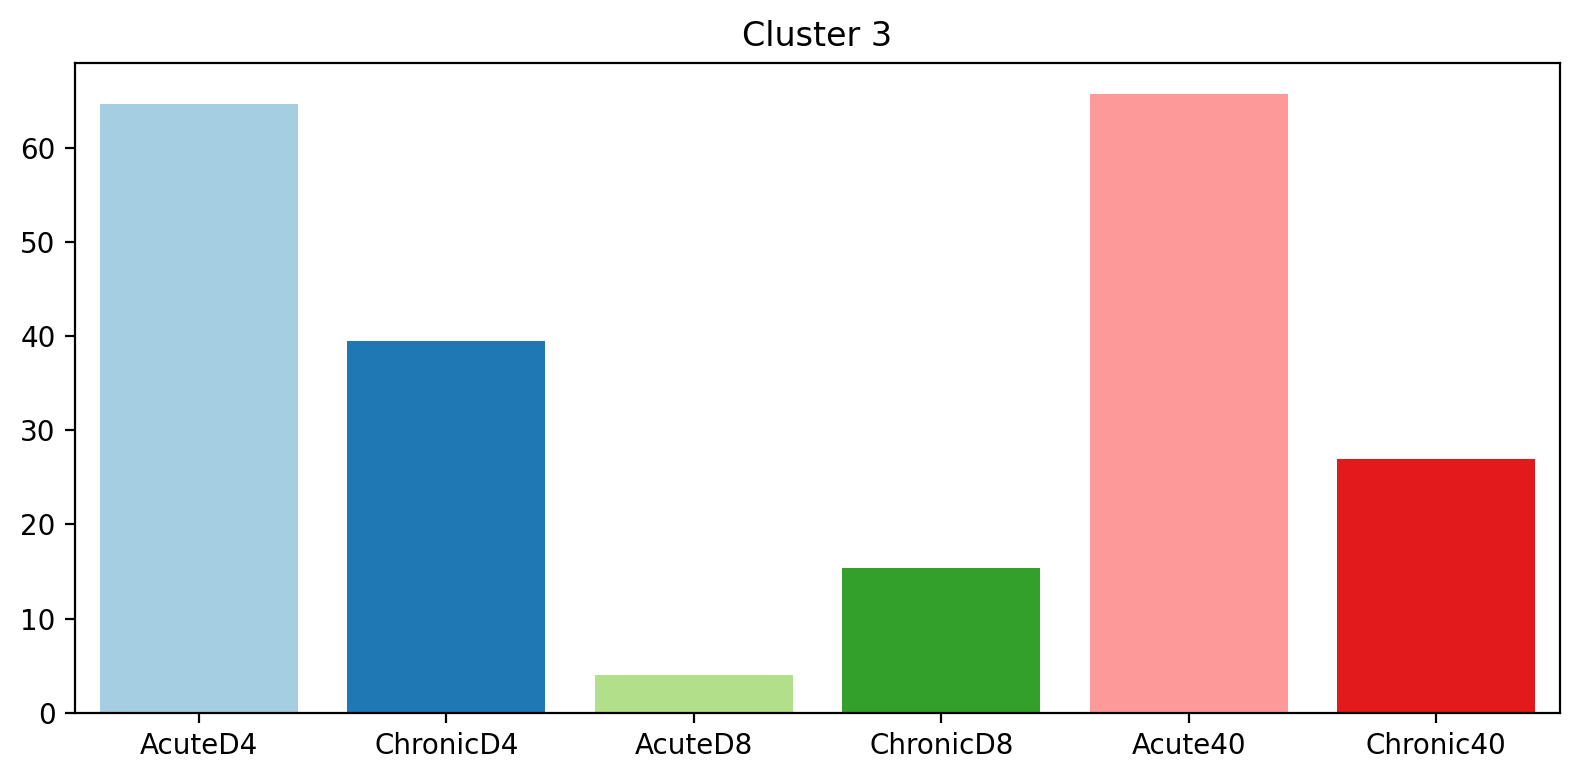

<Figure size 432x288 with 0 Axes>

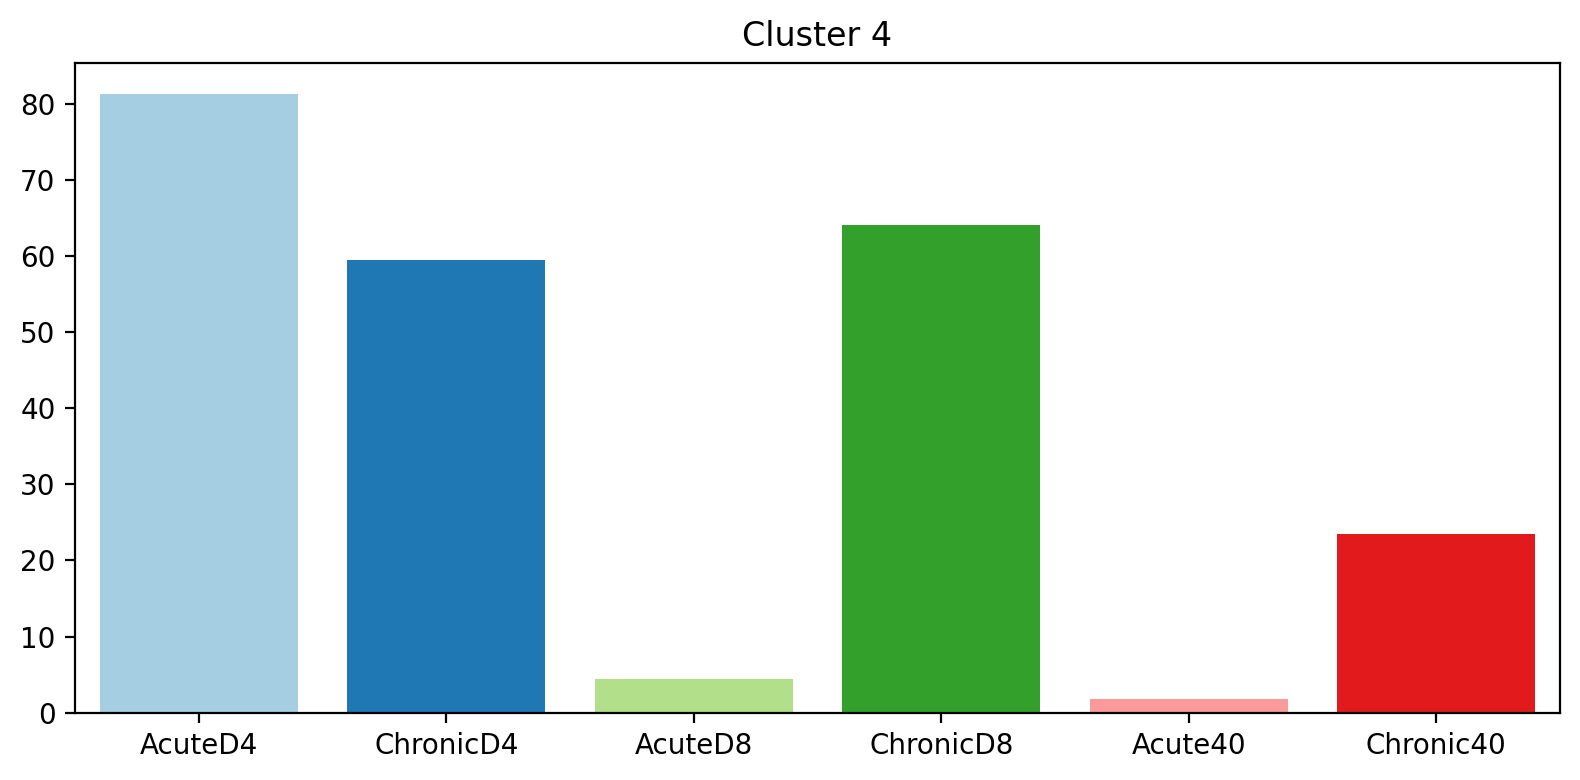

<Figure size 432x288 with 0 Axes>

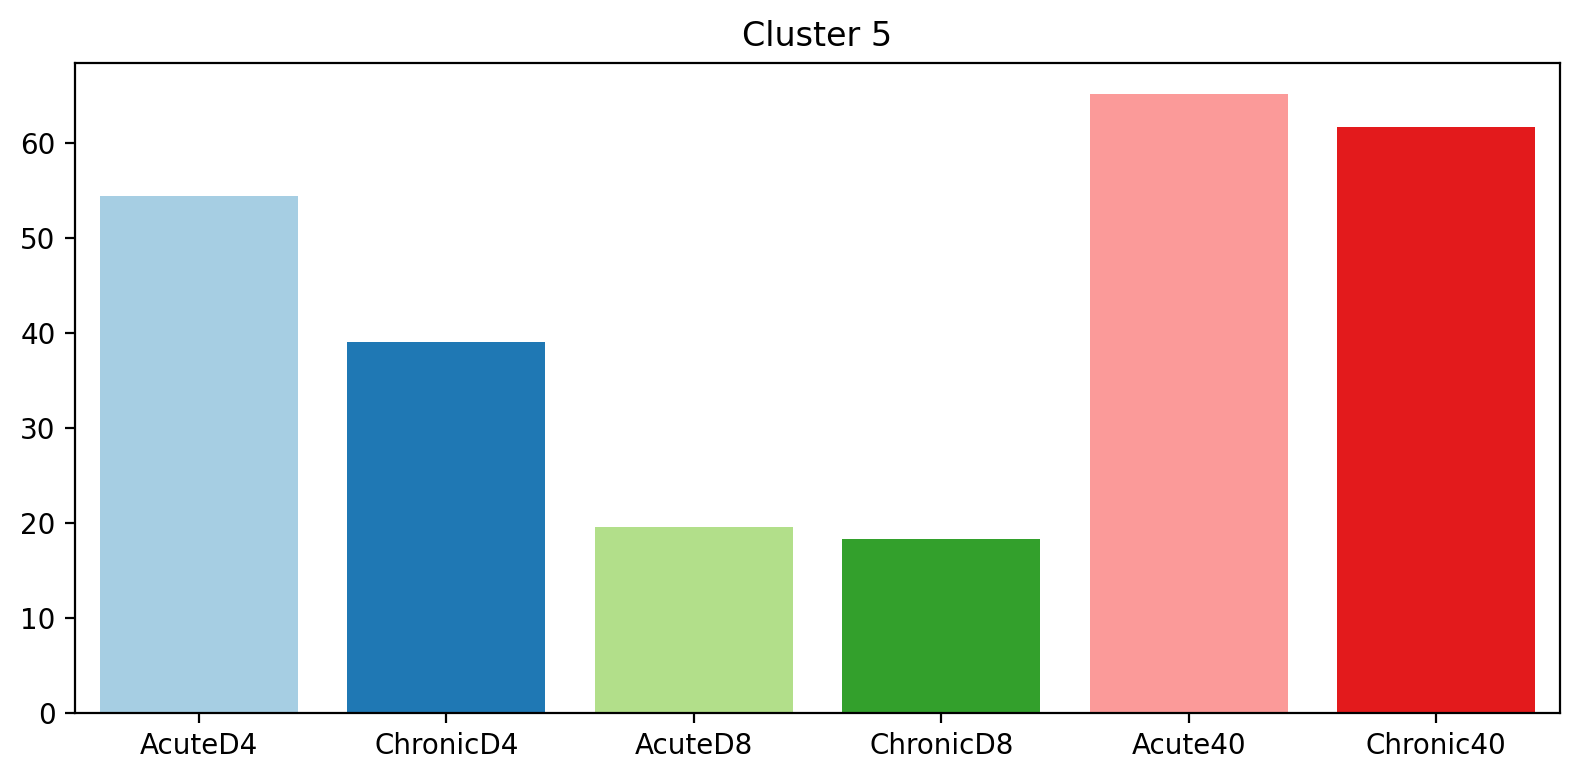

<Figure size 432x288 with 0 Axes>

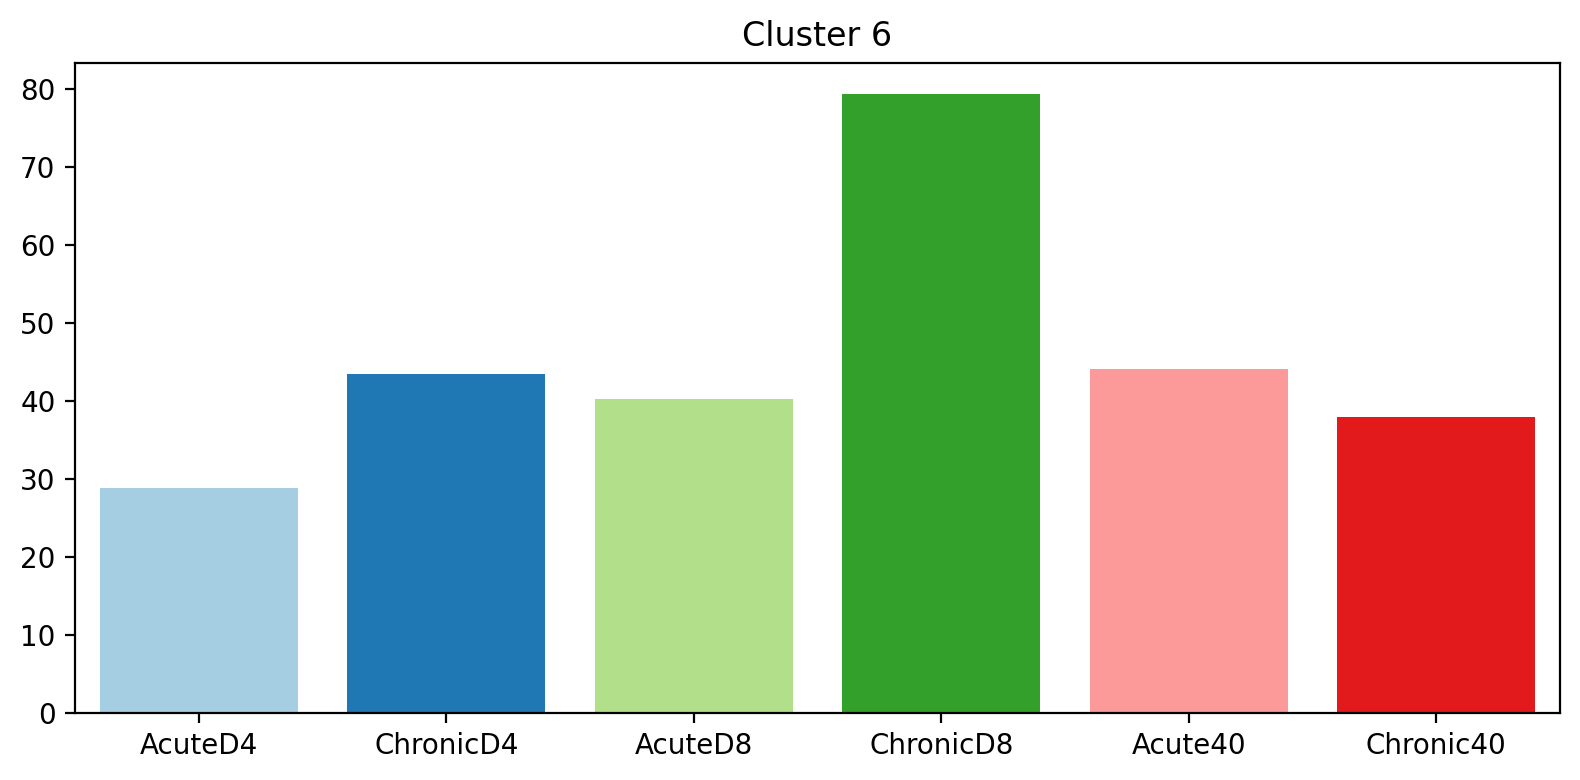

<Figure size 432x288 with 0 Axes>

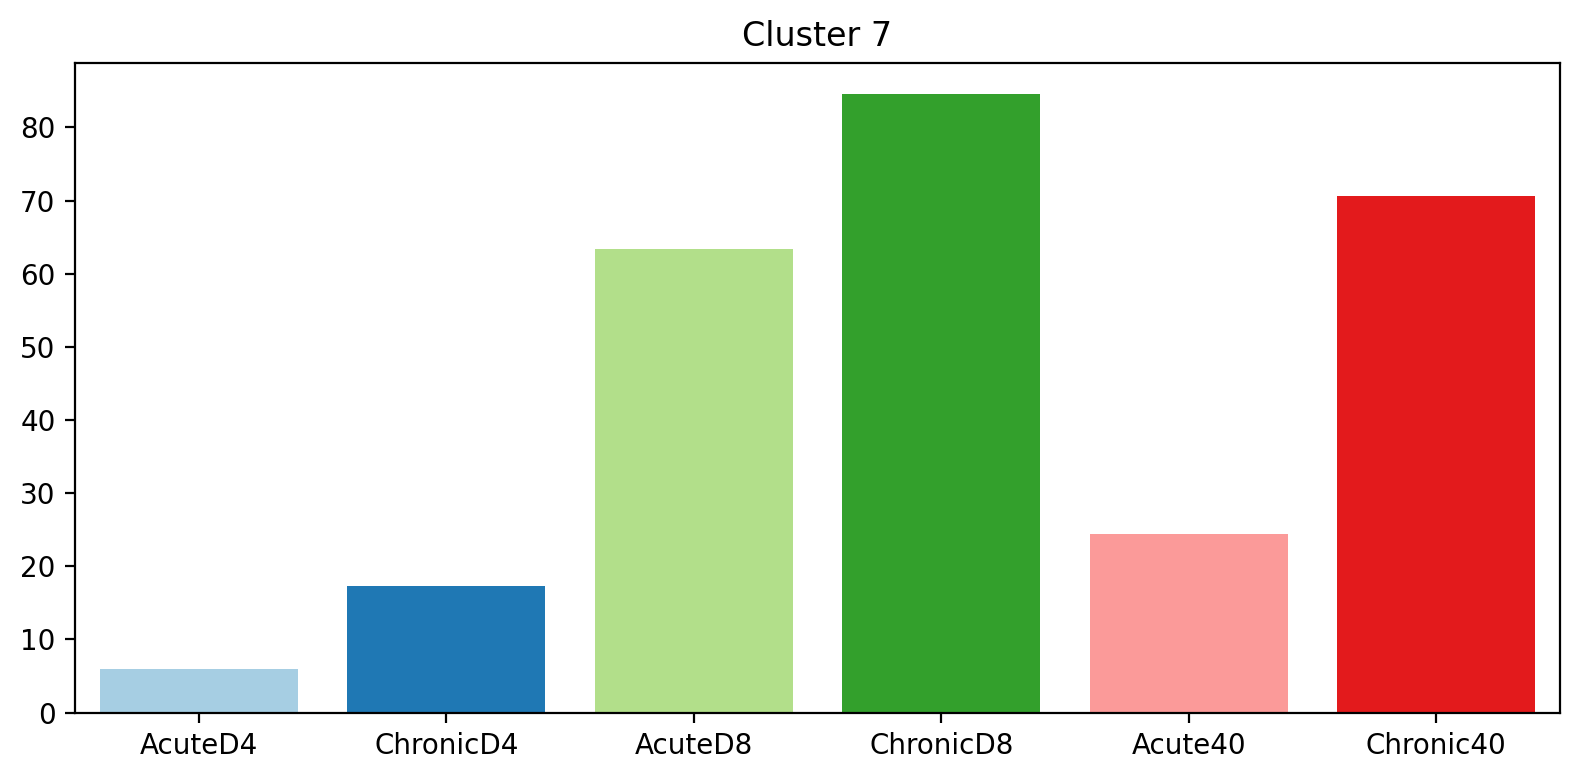

<Figure size 432x288 with 0 Axes>

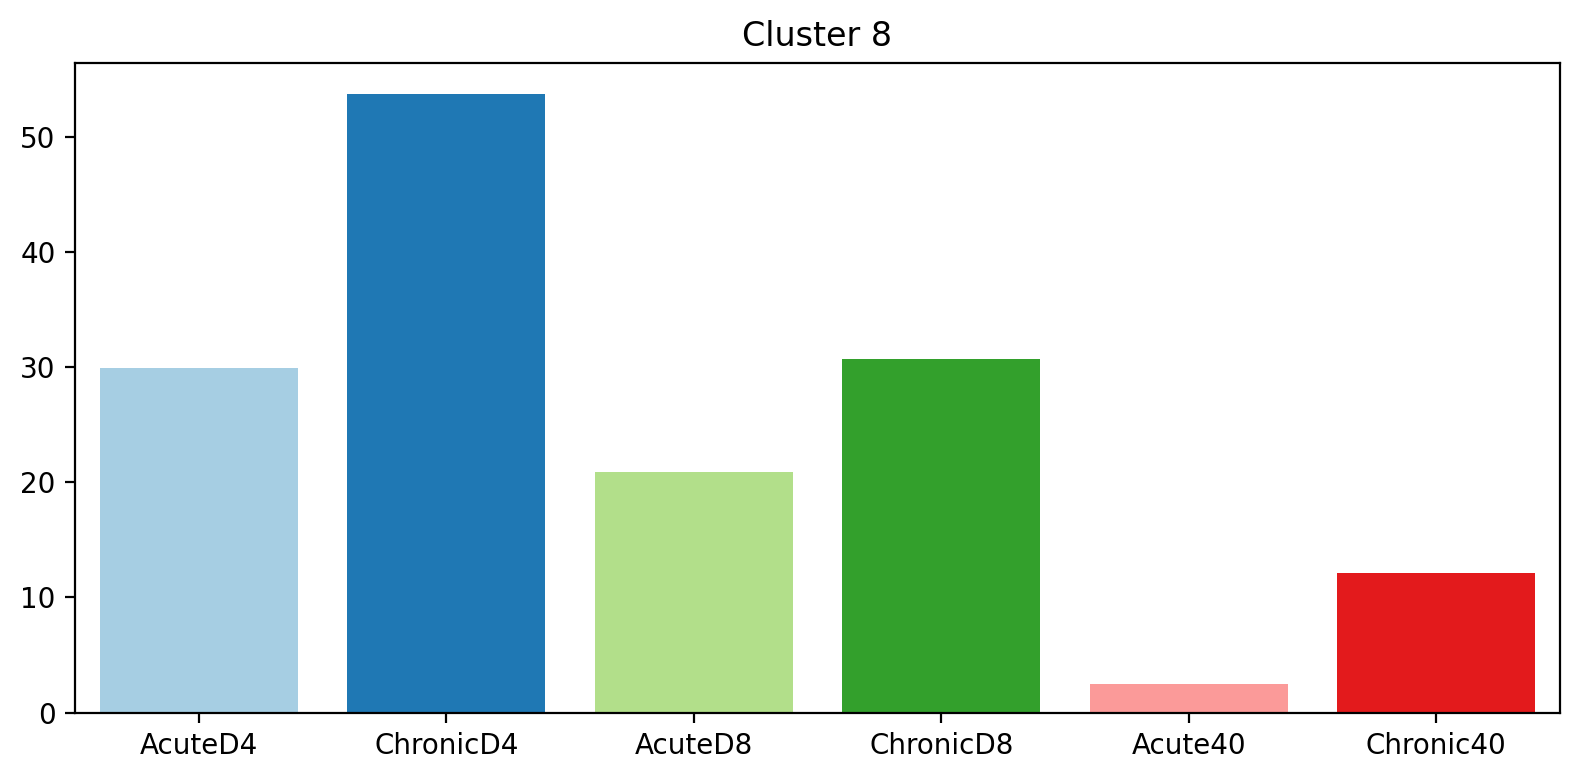

<Figure size 432x288 with 0 Axes>

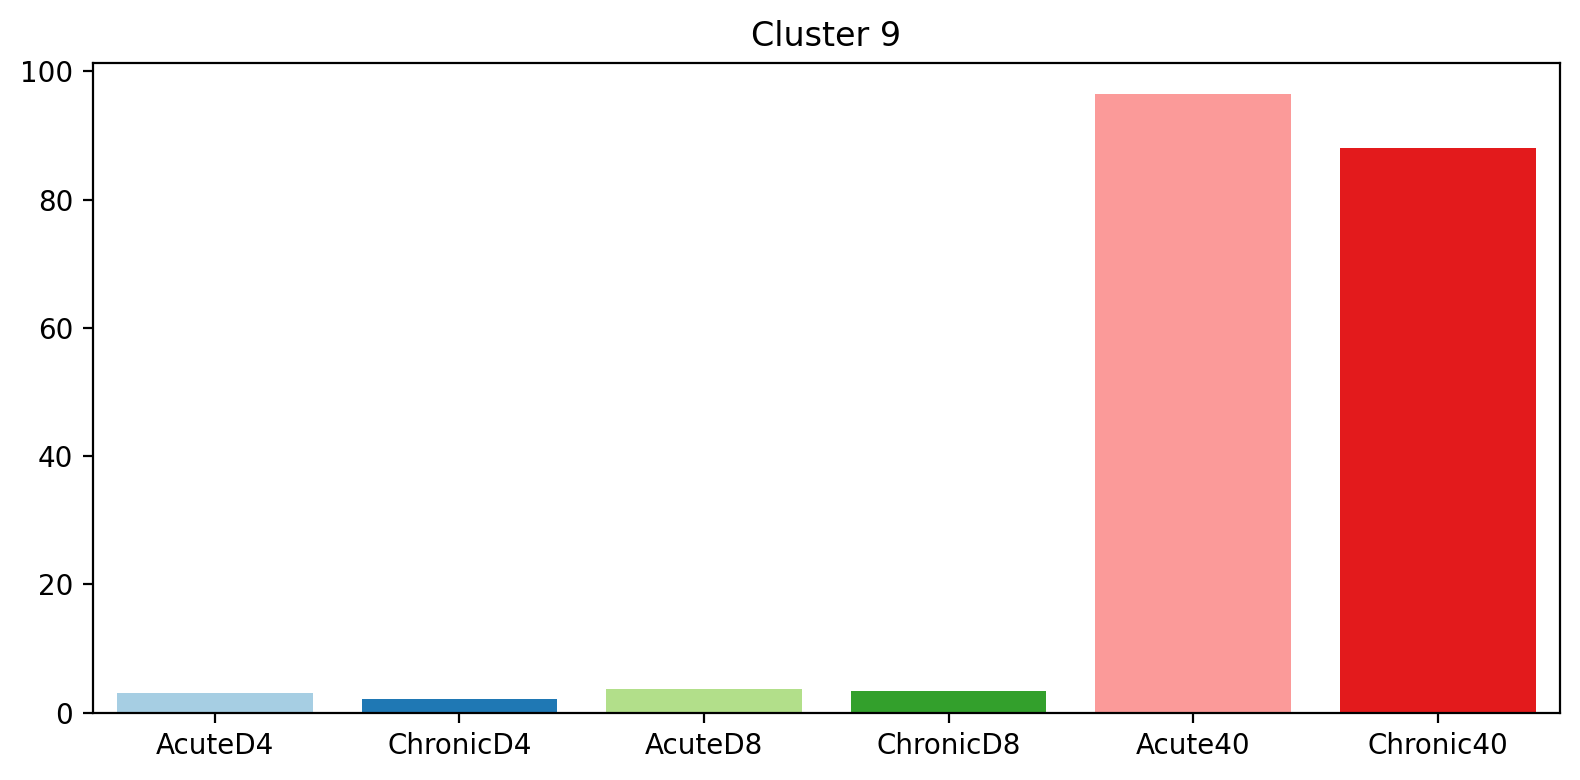

<Figure size 432x288 with 0 Axes>

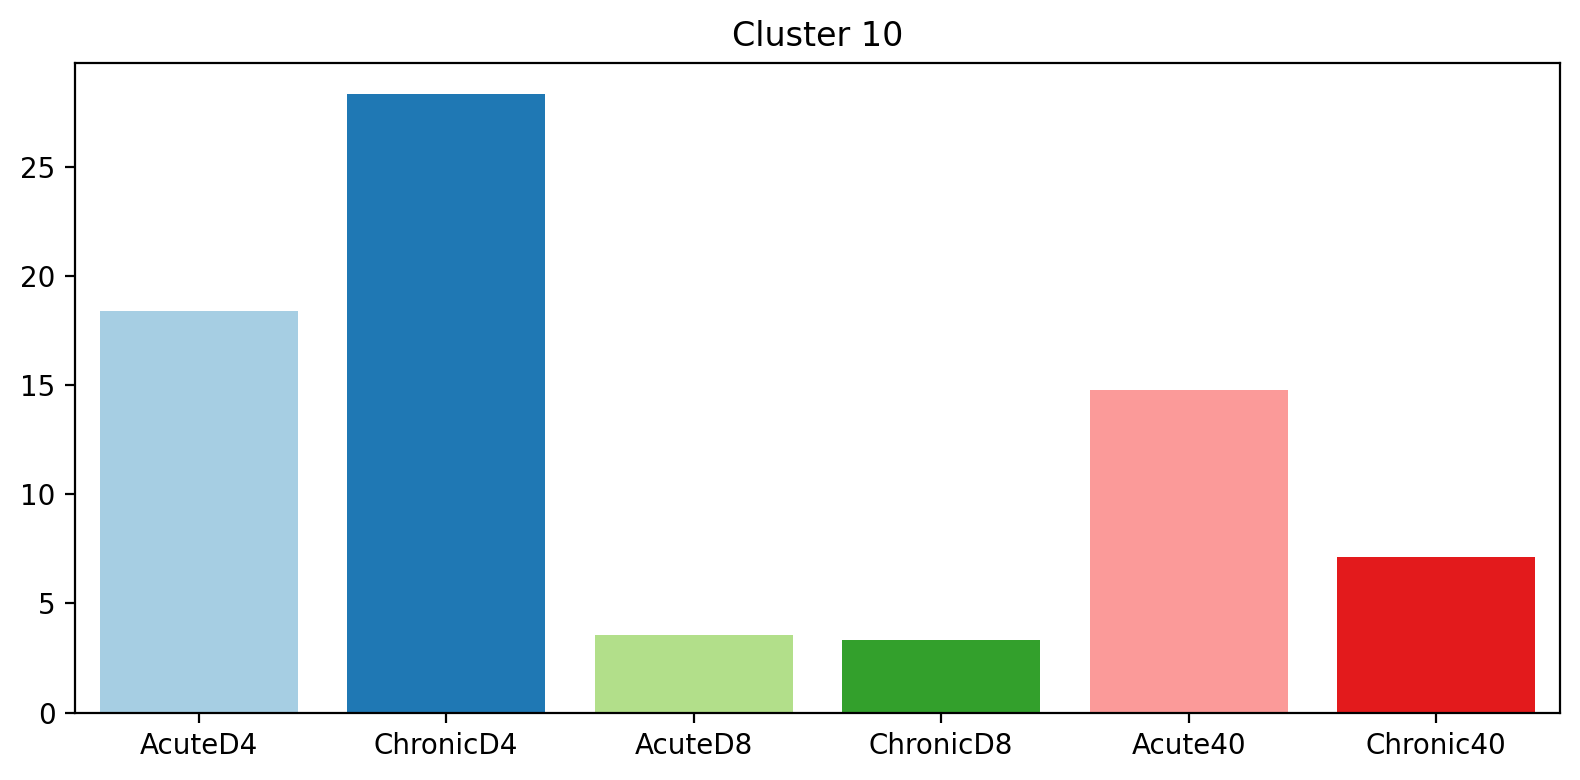

<Figure size 432x288 with 0 Axes>

In [209]:
for clust in range(gene_clusters.max() + 1):
    df = 100* adata.obs['batch'][scale(data_magic.iloc[:, gene_clusters == clust]).mean(axis=1) > 0].value_counts() / adata.obs['batch'].value_counts()
    df = df.loc[cmap.keys()]
    
    #df = prob_per_condition.iloc[gene_clusters == clust].mean(axis=0)
    fig = plt.figure(figsize=(8,4), dpi=200)
    ax = sns.barplot(x=list(df.index), y=df.values)
    
    for i,name in enumerate(cmap.keys()):
        ax.patches[i].set_facecolor(cmap[name])
    
    plt.title(f'Cluster {clust}')
    plt.tight_layout()
    fig.savefig(f'figures/gene_cluster_{clust}_sample_proportion.png', dpi=200)
    plt.show(); plt.clf()

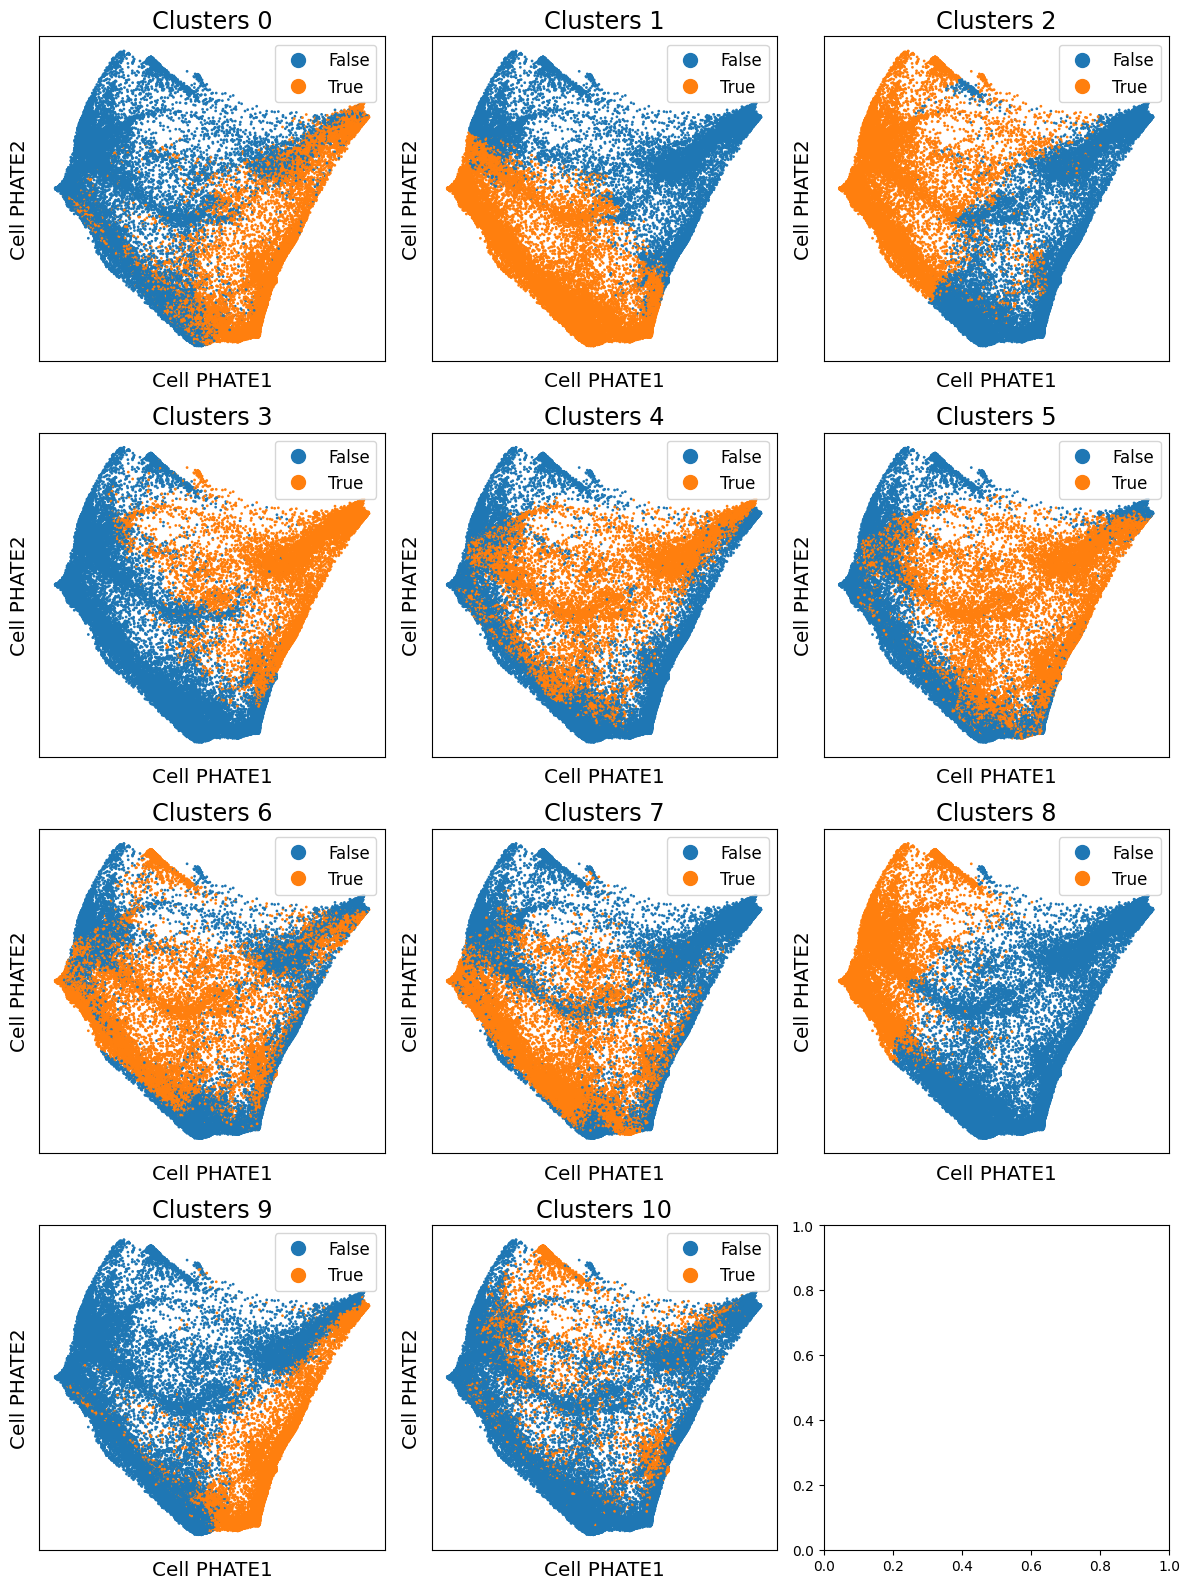

In [170]:
fig, ax = plt.subplots(4,3, figsize=(12,16), dpi=100); ax=ax.flatten()
for clust in range(gene_clusters.max() + 1):
    scprep.plot.scatter2d(adata.obsm['X_phate'], ax=ax[clust],
                          c=scale(data_magic.iloc[:, gene_clusters == clust]).mean(axis=1) > 0,
                          title=f'Clusters {clust}', ticks=None, label_prefix='Cell PHATE')
plt.tight_layout()